In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# ============================================================================
# LOGISTIC REGRESSION IMPLEMENTATION FROM SCRATCH
# ============================================================================

class LogisticRegression:
    """
    Logistic Regression implementation from scratch.

    Mathematical foundation:
    - Model: P(Y=1|x) = σ(w^T x + b) where σ(z) = 1/(1 + e^(-z))
    - Loss: J(w,b) = -1/m Σ[y*log(ŷ) + (1-y)*log(1-ŷ)]
    - Gradient: ∂J/∂w = 1/m Σ(ŷ - y)x
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000,
                 regularization='l2', lambda_reg=0.01, verbose=True):
        """
        Parameters:
        -----------
        learning_rate : float
            Step size for gradient descent (α)
        n_iterations : int
            Number of training iterations
        regularization : str
            'l2' for Ridge, 'l1' for Lasso, None for no regularization
        lambda_reg : float
            Regularization strength (λ)
        verbose : bool
            Print training progress
        """
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.regularization = regularization
        self.lambda_reg = lambda_reg
        self.verbose = verbose

        # Parameters to be learned
        self.weights = None
        self.bias = None

        # Training history
        self.loss_history = []
        self.accuracy_history = []

    def sigmoid(self, z):
        """
        Sigmoid activation function: σ(z) = 1 / (1 + e^(-z))

        Properties:
        - Maps any real number to (0, 1)
        - Derivative: σ'(z) = σ(z)(1 - σ(z))
        """
        # Clip to prevent overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def initialize_parameters(self, n_features):
        """
        Initialize weights and bias.

        Using small random values for weights (Xavier/He initialization concept)
        and zero for bias.
        """
        # Small random weights (helps with convergence)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0

    def compute_loss(self, y_true, y_pred, m):
        """
        Compute cross-entropy loss with optional regularization.

        Cross-entropy: J = -1/m Σ[y*log(ŷ) + (1-y)*log(1-ŷ)]

        L2 regularization: J_reg = J + (λ/2m)||w||²
        L1 regularization: J_reg = J + (λ/m)||w||₁
        """
        # Clip predictions to avoid log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        # Cross-entropy loss
        loss = -1/m * np.sum(y_true * np.log(y_pred) +
                             (1 - y_true) * np.log(1 - y_pred))

        # Add regularization term
        if self.regularization == 'l2':
            loss += (self.lambda_reg / (2 * m)) * np.sum(self.weights ** 2)
        elif self.regularization == 'l1':
            loss += (self.lambda_reg / m) * np.sum(np.abs(self.weights))

        return loss

    def compute_gradients(self, X, y_true, y_pred, m):
        """
        Compute gradients for gradient descent.

        Gradient w.r.t weights: ∂J/∂w = 1/m X^T(ŷ - y) + regularization_term
        Gradient w.r.t bias: ∂J/∂b = 1/m Σ(ŷ - y)
        """
        # Error term: (ŷ - y)
        error = y_pred - y_true

        # Gradient for weights
        dw = (1/m) * np.dot(X.T, error)

        # Add regularization gradient
        if self.regularization == 'l2':
            dw += (self.lambda_reg / m) * self.weights
        elif self.regularization == 'l1':
            dw += (self.lambda_reg / m) * np.sign(self.weights)

        # Gradient for bias
        db = (1/m) * np.sum(error)

        return dw, db

    def fit(self, X, y):
        """
        Train the logistic regression model using gradient descent.

        Algorithm:
        1. Initialize parameters
        2. For each iteration:
           a. Forward pass: compute predictions
           b. Compute loss
           c. Backward pass: compute gradients
           d. Update parameters
        """
        m, n_features = X.shape

        # Initialize parameters
        self.initialize_parameters(n_features)

        # Gradient descent
        for iteration in range(self.n_iterations):
            # Forward pass: compute predictions
            z = np.dot(X, self.weights) + self.bias  # Linear combination
            y_pred = self.sigmoid(z)                  # Apply sigmoid

            # Compute loss
            loss = self.compute_loss(y, y_pred, m)
            self.loss_history.append(loss)

            # Compute accuracy
            y_pred_class = (y_pred >= 0.5).astype(int)
            accuracy = np.mean(y_pred_class == y)
            self.accuracy_history.append(accuracy)

            # Backward pass: compute gradients
            dw, db = self.compute_gradients(X, y, y_pred, m)

            # Update parameters (gradient descent step)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Print progress
            if self.verbose and (iteration % 100 == 0 or iteration == self.n_iterations - 1):
                print(f"Iteration {iteration:4d} | Loss: {loss:.6f} | Accuracy: {accuracy:.4f}")

        return self

    def predict_proba(self, X):
        """
        Predict probabilities P(Y=1|X).

        Returns values between 0 and 1.
        """
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        """
        Predict class labels (0 or 1).

        Uses threshold to convert probabilities to binary predictions.
        Default threshold = 0.5 (decision boundary)
        """
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

    def get_decision_boundary(self):
        """
        Return the decision boundary equation.

        Decision boundary: w^T x + b = 0
        (where P(Y=1|x) = 0.5)
        """
        return self.weights, self.bias

In [22]:
# ============================================================================
# EVALUATION METRICS (FROM SCRATCH)
# ============================================================================

def confusion_matrix(y_true, y_pred):
    """Compute confusion matrix."""
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

def accuracy_score(y_true, y_pred):
    """Compute accuracy: (TP + TN) / Total."""
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    """Compute precision: TP / (TP + FP)."""
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0

def recall_score(y_true, y_pred):
    """Compute recall (sensitivity): TP / (TP + FN)."""
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0

def f1_score(y_true, y_pred):
    """Compute F1 score: 2 * (precision * recall) / (precision + recall)."""
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    return 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

def compute_roc_auc(y_true, y_proba):
    """
    Compute ROC-AUC score from scratch.

    AUC = Probability that model ranks a random positive example
          higher than a random negative example
    """
    # Get all positive and negative examples
    pos_scores = y_proba[y_true == 1]
    neg_scores = y_proba[y_true == 0]

    # Count how many times pos_score > neg_score
    n_correct = 0
    n_total = 0

    for pos_score in pos_scores:
        for neg_score in neg_scores:
            if pos_score > neg_score:
                n_correct += 1
            elif pos_score == neg_score:
                n_correct += 0.5
            n_total += 1

    return n_correct / n_total if n_total > 0 else 0.5


LOGISTIC REGRESSION FROM SCRATCH - DIABETES DATASET

1. Loading Diabetes Dataset...
   Dataset shape: (442, 10)
   Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

   Creating binary classification task:
   - Threshold: 140.50
   - Class 0 (low progression): 221 samples
   - Class 1 (high progression): 221 samples

2. Splitting Dataset...
   Training set: 353 samples
   Test set: 89 samples

3. Scaling Features...
   ✓ Features standardized (mean=0, std=1)

TRAINING LOGISTIC REGRESSION MODEL

Training with L2 regularization (Ridge)...
--------------------------------------------------------------------------------
Iteration    0 | Loss: 0.696654 | Accuracy: 0.4108
Iteration  100 | Loss: 0.482485 | Accuracy: 0.7450
Iteration  200 | Loss: 0.475424 | Accuracy: 0.7507
Iteration  300 | Loss: 0.474169 | Accuracy: 0.7535
Iteration  400 | Loss: 0.473841 | Accuracy: 0.7564
Iteration  500 | Loss: 0.473721 | Accuracy: 0.7535
Iteration  600 | Loss: 0.473657 | Accuracy: 0.

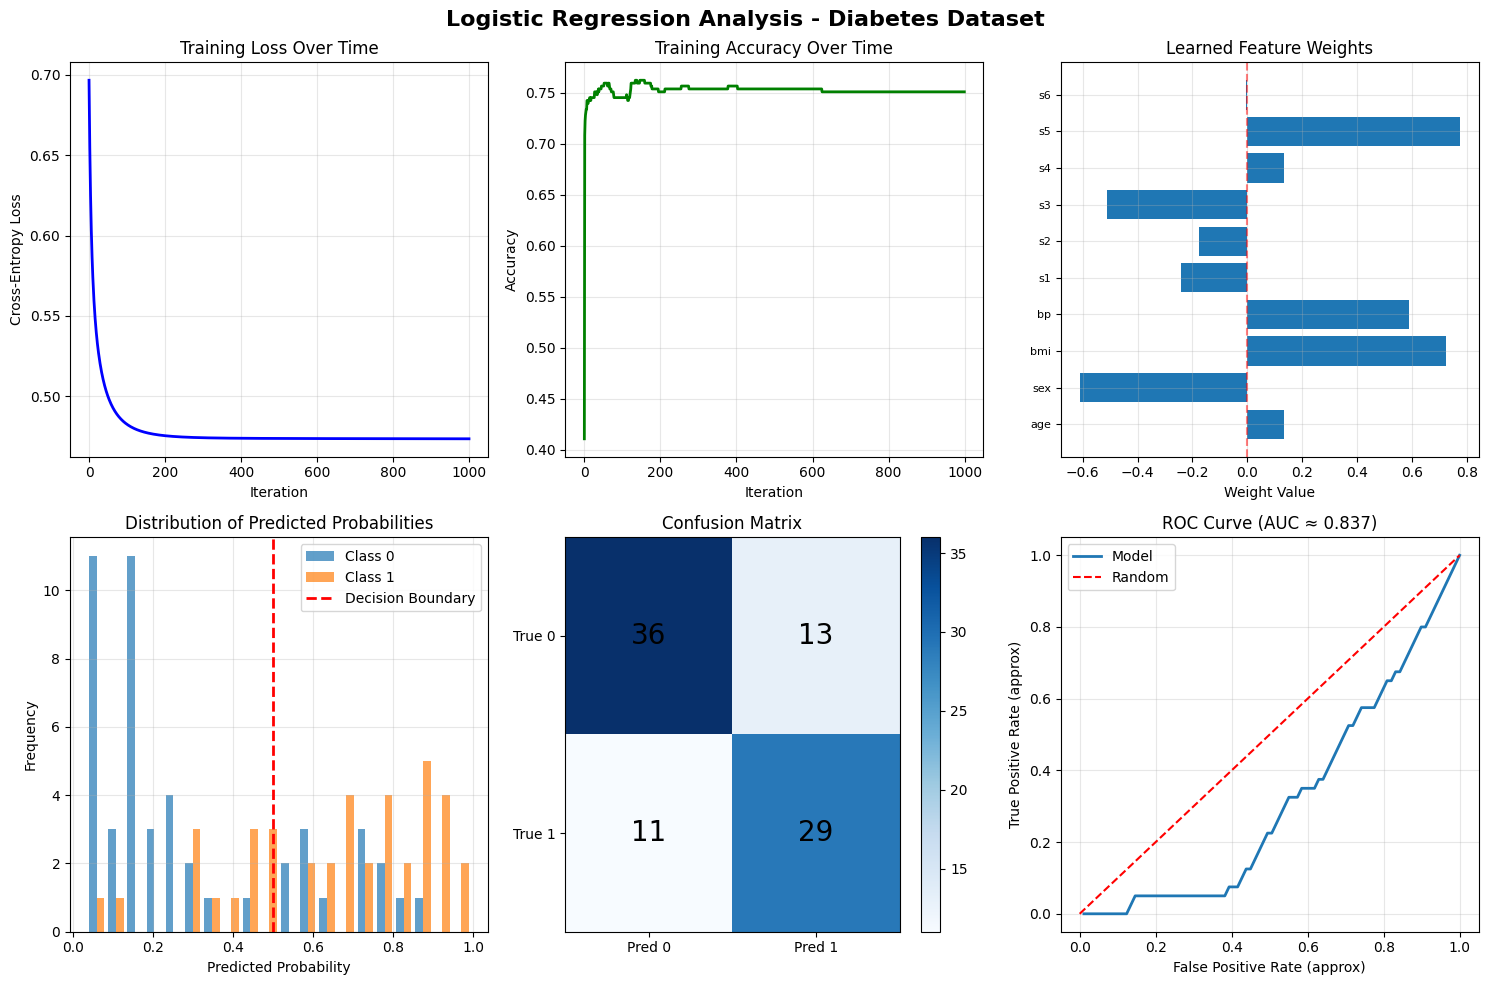

In [23]:
# ============================================================================
# DATA PREPARATION
# ============================================================================

print("=" * 80)
print("LOGISTIC REGRESSION FROM SCRATCH - DIABETES DATASET")
print("=" * 80)

# Load diabetes dataset
print("\n1. Loading Diabetes Dataset...")
diabetes = load_diabetes()
X_full = diabetes.data
y_full = diabetes.target

print(f"   Dataset shape: {X_full.shape}")
print(f"   Features: {diabetes.feature_names}")

# Convert to binary classification
# Target is disease progression (continuous), we'll threshold it
# to create binary classes: high progression (1) vs low progression (0)
median_target = np.median(y_full)
y_binary = (y_full > median_target).astype(int)

print(f"\n   Creating binary classification task:")
print(f"   - Threshold: {median_target:.2f}")
print(f"   - Class 0 (low progression): {np.sum(y_binary == 0)} samples")
print(f"   - Class 1 (high progression): {np.sum(y_binary == 1)} samples")

# Split data
print("\n2. Splitting Dataset...")
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_binary, test_size=0.2, random_state=42
)
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set: {X_test.shape[0]} samples")

# Feature scaling (important for gradient descent!)
print("\n3. Scaling Features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("   ✓ Features standardized (mean=0, std=1)")

# ============================================================================
# MODEL TRAINING
# ============================================================================

print("\n" + "=" * 80)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("=" * 80)

# Train model
model = LogisticRegression(
    learning_rate=0.1,
    n_iterations=1000,
    regularization='l2',
    lambda_reg=0.01,
    verbose=True
)

print("\nTraining with L2 regularization (Ridge)...")
print("-" * 80)
model.fit(X_train_scaled, y_train)

# ============================================================================
# MODEL EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

# Predictions on test set
y_pred_proba = model.predict_proba(X_test_scaled)
y_pred = model.predict(X_test_scaled)

# Compute metrics
print("\nTest Set Performance:")
print("-" * 40)

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("                Predicted")
print("              0         1")
print(f"Actual  0    {conf_matrix[0,0]:3d}      {conf_matrix[0,1]:3d}")
print(f"        1    {conf_matrix[1,0]:3d}      {conf_matrix[1,1]:3d}")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = compute_roc_auc(y_test, y_pred_proba)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Feature importance (weight magnitudes)
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE (|weights|)")
print("=" * 80)

feature_importance = np.abs(model.weights)
feature_indices = np.argsort(feature_importance)[::-1]

print("\nTop features by importance:")
print("-" * 40)
for i, idx in enumerate(feature_indices[:5]):
    print(f"{i+1}. {diabetes.feature_names[idx]:10s}: {model.weights[idx]:+.4f}")

# ============================================================================
# VISUALIZATION
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Logistic Regression Analysis - Diabetes Dataset',
             fontsize=16, fontweight='bold')

# Plot 1: Training Loss
axes[0, 0].plot(model.loss_history, color='blue', linewidth=2)
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Cross-Entropy Loss')
axes[0, 0].set_title('Training Loss Over Time')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Training Accuracy
axes[0, 1].plot(model.accuracy_history, color='green', linewidth=2)
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training Accuracy Over Time')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Feature Weights
axes[0, 2].barh(range(len(model.weights)), model.weights)
axes[0, 2].set_yticks(range(len(model.weights)))
axes[0, 2].set_yticklabels(diabetes.feature_names, fontsize=8)
axes[0, 2].set_xlabel('Weight Value')
axes[0, 2].set_title('Learned Feature Weights')
axes[0, 2].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Predicted Probabilities Distribution
axes[1, 0].hist([y_pred_proba[y_test == 0], y_pred_proba[y_test == 1]],
                bins=20, label=['Class 0', 'Class 1'], alpha=0.7)
axes[1, 0].axvline(x=0.5, color='red', linestyle='--',
                   linewidth=2, label='Decision Boundary')
axes[1, 0].set_xlabel('Predicted Probability')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Predicted Probabilities')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Confusion Matrix Heatmap
im = axes[1, 1].imshow(conf_matrix, cmap='Blues', aspect='auto')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(['Pred 0', 'Pred 1'])
axes[1, 1].set_yticklabels(['True 0', 'True 1'])
axes[1, 1].set_title('Confusion Matrix')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = axes[1, 1].text(j, i, conf_matrix[i, j],
                              ha="center", va="center", color="black", fontsize=20)
plt.colorbar(im, ax=axes[1, 1])

# Plot 6: ROC-like curve (simplified)
# Sort by predicted probability
sorted_indices = np.argsort(y_pred_proba)
y_test_sorted = y_test[sorted_indices]
cumulative_positives = np.cumsum(y_test_sorted) / np.sum(y_test_sorted)
cumulative_total = np.arange(1, len(y_test_sorted) + 1) / len(y_test_sorted)

axes[1, 2].plot(cumulative_total, cumulative_positives, linewidth=2, label='Model')
axes[1, 2].plot([0, 1], [0, 1], 'r--', label='Random')
axes[1, 2].set_xlabel('False Positive Rate (approx)')
axes[1, 2].set_ylabel('True Positive Rate (approx)')
axes[1, 2].set_title(f'ROC Curve (AUC ≈ {roc_auc:.3f})')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_analysis.png', dpi=150, bbox_inches='tight')
print("\n✓ Visualizations saved as 'logistic_regression_analysis.png'")

# ============================================================================
# MATHEMATICAL INSIGHTS
# ============================================================================

print("\n" + "=" * 80)
print("MATHEMATICAL INSIGHTS")
print("=" * 80)

print("\n1. Model Parameters:")
print(f"   - Number of weights: {len(model.weights)}")
print(f"   - Bias term: {model.bias:.6f}")
print(f"   - L2 norm of weights: {np.linalg.norm(model.weights):.6f}")

print("\n2. Decision Boundary:")
print(f"   - Equation: w^T x + b = 0")
print(f"   - Points where P(Y=1|x) = 0.5")

print("\n3. Interpretation (Log-Odds):")
print("   - Each weight represents change in log-odds per unit feature change")
print("   - Positive weight → increases probability of class 1")
print("   - Negative weight → decreases probability of class 1")

print("\n4. Example Predictions:")
print("-" * 40)
for i in range(min(5, len(y_test))):
    print(f"   Sample {i+1}: True={y_test[i]}, "
          f"Pred={y_pred[i]}, Prob={y_pred_proba[i]:.4f}")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print("\nKey Takeaways:")
print("• Logistic regression models P(Y=1|x) using sigmoid function")
print("• Optimized using gradient descent with cross-entropy loss")
print("• L2 regularization prevents overfitting")
print("• Weights indicate feature importance and direction of effect")
print("• Model achieves reasonable performance on diabetes progression prediction")

plt.show()

In [8]:
from sklearn.metrics import confusion_matrix

In [9]:
from sklearn.metrics import accuracy_score

In [12]:
from sklearn.metrics import precision_score

In [21]:
from sklearn.metrics import compute_roc_auc

ImportError: cannot import name 'compute_roc_auc' from 'sklearn.metrics' (/usr/local/lib/python3.12/dist-packages/sklearn/metrics/__init__.py)